In [43]:
import numpy as np
import os
import pandas as pd

In [44]:

# LOAD DATA

X_tbi = np.load(r"E:\aditi_eeg\visual_eeg\tbi_visual\X.npy")
y_tbi = np.load(r"E:\aditi_eeg\visual_eeg\tbi_visual\y.npy")

X_non_tbi = np.load(r"E:\aditi_eeg\visual_eeg\non_tbi_visual\X.npy")
y_non_tbi = np.load(r"E:\aditi_eeg\visual_eeg\non_tbi_visual\y.npy")


In [45]:

# COMBINE THE DATA 
X = np.vstack((X_tbi, X_non_tbi))
y = np.concatenate((y_tbi, y_non_tbi))

print("Final Shape:", X.shape)
print("Labels:", np.bincount(y))

Final Shape: (3798, 64)
Labels: [2095 1703]


In [32]:

# SAVE PATH OF DATA 
save_path = r"E:\aditi_eeg\visual_eeg\final_dataset"
os.makedirs(save_path, exist_ok=True)


In [33]:
#  DELETE OLD FILES
files_to_delete = [
    "X.npy", "y.npy", "dataset.npz",
    "final_dataset.csv", "final_dataset.xlsx"
]

for file in files_to_delete:
    file_path = os.path.join(save_path, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted old file: {file}")

Deleted old file: X.npy
Deleted old file: y.npy
Deleted old file: dataset.npz
Deleted old file: final_dataset.csv
Deleted old file: final_dataset.xlsx


In [34]:

# SAVE NEW FILES

np.save(os.path.join(save_path, "X.npy"), X)
np.save(os.path.join(save_path, "y.npy"), y)
np.savez(os.path.join(save_path, "dataset.npz"), X=X, y=y)

In [35]:

# SAVE CSV & EXCEL

columns = [
    "Pz_amp", "Pz_lat",
    "Cz_amp", "Cz_lat",
    "P3_amp", "P3_lat",
    "P4_amp", "P4_lat"
]

df = pd.DataFrame(X, columns=columns)
df["Label"] = y

df.to_csv(os.path.join(save_path, "final_dataset.csv"), index=False)
df.to_excel(os.path.join(save_path, "final_dataset.xlsx"), index=False)

print(" Fresh dataset saved (old files removed)")

 Fresh dataset saved (old files removed)


In [36]:
print(df.head())

     Pz_amp    Pz_lat    Cz_amp    Cz_lat    P3_amp    P3_lat    P4_amp  \
0  0.000000  0.000000  0.000000  0.000000  0.002595  0.393555  0.002595   
1  0.000358  0.282227  0.000396  0.282227  0.000170  0.447266  0.000170   
2  0.000025  0.358398  0.000045  0.401367  0.000025  0.358398  0.000025   
3  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4  0.000057  0.354492  0.000071  0.360352  0.000019  0.349609  0.000019   

     P4_lat  Label  
0  0.393555      1  
1  0.447266      1  
2  0.358398      1  
3  0.000000      1  
4  0.349609      1  


In [37]:
print(df[["Pz_amp", "Pz_lat"]])

        Pz_amp    Pz_lat
0     0.000000  0.000000
1     0.000358  0.282227
2     0.000025  0.358398
3     0.000000  0.000000
4     0.000057  0.354492
...        ...       ...
6170  0.000042  0.447266
6171  0.000482  0.446289
6172  0.000331  0.444336
6173  0.000000  0.000000
6174  0.000030  0.282227

[6175 rows x 2 columns]


In [38]:
print(df["Label"].value_counts())

Label
1    4080
0    2095
Name: count, dtype: int64


In [39]:
import numpy as np

#Load TBI
X_tbi = np.load(r"E:\aditi_eeg\visual_eeg\tbi_visual\X.npy")
y_tbi = np.load(r"E:\aditi_eeg\visual_eeg\tbi_visual\y.npy")

#Load Non-TBI
X_non = np.load(r"E:\aditi_eeg\visual_eeg\non_tbi_visual\X.npy")
y_non = np.load(r"E:\aditi_eeg\visual_eeg\non_tbi_visual\y.npy")


#Combine
X = np.vstack((X_tbi, X_non))
y = np.concatenate((y_tbi, y_non))


print("Final Shape:", X.shape)
print("Unique labels:", np.unique(y))
print("Label counts:", np.bincount(y.astype(int)))

Final Shape: (6175, 8)
Unique labels: [0 1]
Label counts: [2095 4080]


In [40]:
#  SAVE PATH

save_path = r"E:\aditi_eeg\visual_eeg\final_dataset"
os.makedirs(save_path, exist_ok=True)

# DELETE OLD FILES
files_to_delete = [
    "X_final.npy",
    "y_final.npy",
    "final_dataset.csv",
    "final_dataset.xlsx"
]

for file in files_to_delete:
    file_path = os.path.join(save_path, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted old file: {file}")

#  SAVE NEW FILES

np.save(os.path.join(save_path, "X_final.npy"), X)
np.save(os.path.join(save_path, "y_final.npy"), y)

# SAVE CSV & EXCEL

columns = [
    "Pz_amp", "Pz_lat",
    "Cz_amp", "Cz_lat",
    "P3_amp", "P3_lat",
    "P4_amp", "P4_lat"
]

df = pd.DataFrame(X, columns=columns)
df["Label"] = y

df.to_csv(os.path.join(save_path, "final_dataset.csv"), index=False)
df.to_excel(os.path.join(save_path, "final_dataset.xlsx"), index=False)

print("Old files deleted + New dataset saved cleanly")

Deleted old file: X_final.npy
Deleted old file: y_final.npy
Deleted old file: final_dataset.csv
Deleted old file: final_dataset.xlsx
Old files deleted + New dataset saved cleanly


In [41]:
import numpy as np

X = np.load(r"E:\aditi_eeg\visual_eeg\final_dataset\X_final.npy")
y = np.load(r"E:\aditi_eeg\visual_eeg\final_dataset\y_final.npy")

print("Shape:", X.shape)
print("Labels:", np.unique(y))

Shape: (6175, 8)
Labels: [0 1]


In [42]:
# Pz channel (first 2 columns)
p300_amp = X[:, 0]
p300_lat = X[:, 1]

# Separate classes
tbi_amp = p300_amp[y == 1]
non_amp = p300_amp[y == 0]

tbi_lat = p300_lat[y == 1]
non_lat = p300_lat[y == 0]

# Mean values
print("TBI Amplitude:", np.mean(tbi_amp))
print("Non-TBI Amplitude:", np.mean(non_amp))

print("TBI Latency:", np.mean(tbi_lat))
print("Non-TBI Latency:", np.mean(non_lat))

TBI Amplitude: 4.655052935078107e-05
Non-TBI Amplitude: 8.967431767698408e-05
TBI Latency: 0.24381875957414215
Non-TBI Latency: 0.23867607025656323


C:\Users\HP\AppData\Local\Temp\ipykernel_39428\3564295733.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_amp, tbi_amp], labels=["Non-TBI", "TBI"])


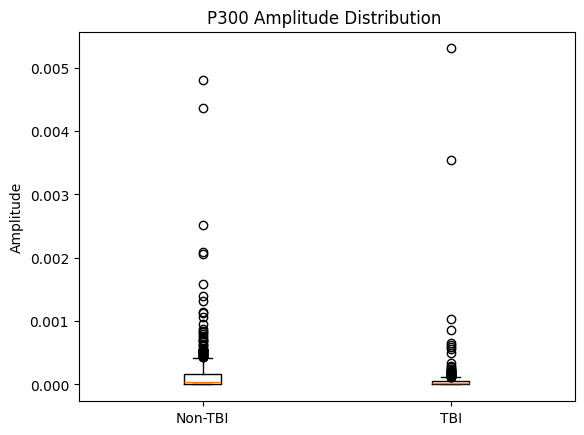

In [15]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot([non_amp, tbi_amp], labels=["Non-TBI", "TBI"])
plt.title("P300 Amplitude Distribution ")
plt.ylabel("Amplitude")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_39428\3839328567.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_lat, tbi_lat], labels=["Non-TBI", "TBI"])


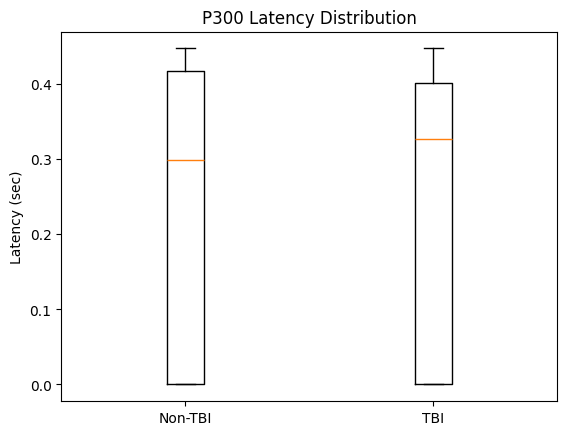

In [16]:
plt.figure()

plt.boxplot([non_lat, tbi_lat], labels=["Non-TBI", "TBI"])
plt.title("P300 Latency Distribution")
plt.ylabel("Latency (sec)")

plt.show()

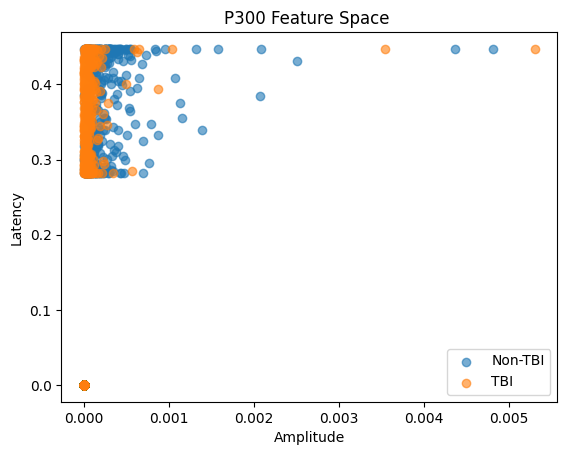

In [17]:
plt.figure()

plt.scatter(non_amp, non_lat, label="Non-TBI", alpha=0.6)
plt.scatter(tbi_amp, tbi_lat, label="TBI", alpha=0.6)

plt.xlabel("Amplitude")
plt.ylabel("Latency")
plt.title("P300 Feature Space ")
plt.legend()

plt.show()

In [18]:
channels = ["Pz", "Cz", "P3", "P4"]

for i, ch in enumerate(channels):
    amp = X[:, i*2]
    lat = X[:, i*2 + 1]

    print(f"\n{ch}")
    print("TBI mean amp:", np.mean(amp[y==1]))
    print("Non-TBI mean amp:", np.mean(amp[y==0]))


Pz
TBI mean amp: 5.433439983389005e-05
Non-TBI mean amp: 0.0001477394689947873

Cz
TBI mean amp: 5.7464418455380085e-05
Non-TBI mean amp: 0.00015303315065392985

P3
TBI mean amp: 7.89894858834506e-05
Non-TBI mean amp: 0.0001463094245116539

P4
TBI mean amp: 0.00010461355800087082
Non-TBI mean amp: 0.0001463094245116539



===== DATA SHAPE =====
X shape: (3798, 36)
y shape: (3798,)

===== CLASS DISTRIBUTION =====
Class 0: 2095 samples
Class 1: 1703 samples

===== DATA QUALITY CHECK =====
NaN values: 0
Inf values: 0

===== DATA PREVIEW =====
         Pz_amp    Pz_lat       Pz_mean    Pz_std      Pz_delta      Pz_theta  \
0  5.331668e-05  0.394531  3.513937e-05  0.000025  1.203070e-10  1.801561e-13   
1  7.197222e-06  0.393555  1.329427e-08  0.000004  1.406815e-11  3.028868e-12   
2 -1.601801e-07  0.280273 -3.630325e-07  0.000006  2.114896e-11  2.573272e-12   
3 -1.295794e-06  0.297852 -5.194043e-06  0.000006  1.164307e-11  1.343342e-12   
4 -5.381216e-06  0.445312 -7.943325e-06  0.000006  7.575702e-12  1.442465e-12   

       Pz_alpha       Pz_beta  Pz_adl_score    Cz_amp  ...    P4_amp  \
0  2.666108e-12  2.058687e-12      0.000005  0.000056  ... -0.000004   
1  1.848069e-12  2.069337e-12      0.000004  0.000014  ...  0.000012   
2  1.245847e-12  3.735812e-12      0.000005  0.000030  ...  0.000001   
3 

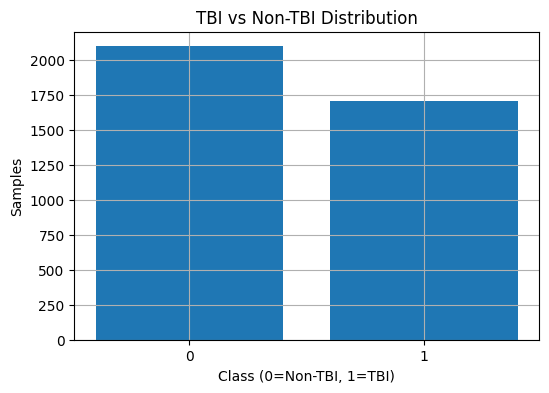

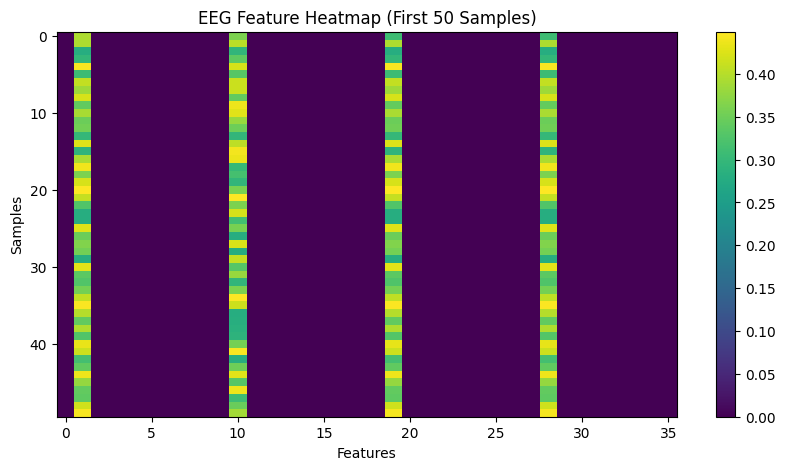

In [57]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# ================= LOAD DATA =================
X_tbi = np.load(r"E:\aditi_eeg\visual_eeg\tbi_visual\X.npy")
y_tbi = np.load(r"E:\aditi_eeg\visual_eeg\tbi_visual\y.npy")

X_non_tbi = np.load(r"E:\aditi_eeg\visual_eeg\non_tbi_visual\X.npy")
y_non_tbi = np.load(r"E:\aditi_eeg\visual_eeg\non_tbi_visual\y.npy")

# ================= CONCATENATION =================
X = np.vstack((X_tbi, X_non_tbi))
y = np.concatenate((y_tbi, y_non_tbi))

print("\n===== DATA SHAPE =====")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ================= LABEL DISTRIBUTION =================
unique, counts = np.unique(y, return_counts=True)

print("\n===== CLASS DISTRIBUTION =====")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

# ================= DATA QUALITY CHECK =================
print("\n===== DATA QUALITY CHECK =====")
print("NaN values:", np.isnan(X).sum())
print("Inf values:", np.isinf(X).sum())

# ================= SAFE COLUMN NAMING (IMPORTANT FIX) =================
channels = ['Pz', 'Cz', 'P3', 'P4']

feature_names = [
    "amp", "lat",
    "mean", "std",
    "delta", "theta", "alpha", "beta",
    "adl_score"
]

columns = []

for ch in channels:
    for f in feature_names:
        columns.append(f"{ch}_{f}")
# ================= DATAFRAME =================
df = pd.DataFrame(X, columns=columns)
df["Label"] = y

print("\n===== DATA PREVIEW =====")
print(df.head())

# ================= SAVE PATH =================
save_path = r"E:\aditi_eeg\visual_eeg\final_dataset"
os.makedirs(save_path, exist_ok=True)

# ================= CLEAN OLD FILES =================
files_to_delete = [
    "X.npy", "y.npy",
    "dataset.npz",
    "final_dataset.csv",
    "final_dataset.xlsx"
]

for file in files_to_delete:
    file_path = os.path.join(save_path, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {file}")

# ================= SAVE FILES =================
np.save(os.path.join(save_path, "X.npy"), X)
np.save(os.path.join(save_path, "y.npy"), y)

df.to_csv(os.path.join(save_path, "final_dataset.csv"), index=False)
df.to_excel(os.path.join(save_path, "final_dataset.xlsx"), index=False)
np.savez(os.path.join(save_path, "dataset.npz"), X=X, y=y)

print("\n===== FILES SAVED SUCCESSFULLY =====")

# ================= VISUALIZATION 1: CLASS BALANCE =================
plt.figure(figsize=(6,4))
plt.bar(unique, counts)
plt.title("TBI vs Non-TBI Distribution")
plt.xlabel("Class (0=Non-TBI, 1=TBI)")
plt.ylabel("Samples")
plt.xticks(unique)
plt.grid()
plt.show()

# ================= VISUALIZATION 2: FEATURE HEATMAP =================
plt.figure(figsize=(10,5))
plt.imshow(X[:50], aspect='auto')
plt.title("EEG Feature Heatmap (First 50 Samples)")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.colorbar()
plt.show()

In [58]:
print(df.head())

         Pz_amp    Pz_lat       Pz_mean    Pz_std      Pz_delta      Pz_theta  \
0  5.331668e-05  0.394531  3.513937e-05  0.000025  1.203070e-10  1.801561e-13   
1  7.197222e-06  0.393555  1.329427e-08  0.000004  1.406815e-11  3.028868e-12   
2 -1.601801e-07  0.280273 -3.630325e-07  0.000006  2.114896e-11  2.573272e-12   
3 -1.295794e-06  0.297852 -5.194043e-06  0.000006  1.164307e-11  1.343342e-12   
4 -5.381216e-06  0.445312 -7.943325e-06  0.000006  7.575702e-12  1.442465e-12   

       Pz_alpha       Pz_beta  Pz_adl_score    Cz_amp  ...    P4_amp  \
0  2.666108e-12  2.058687e-12      0.000005  0.000056  ... -0.000004   
1  1.848069e-12  2.069337e-12      0.000004  0.000014  ...  0.000012   
2  1.245847e-12  3.735812e-12      0.000005  0.000030  ...  0.000001   
3  1.585911e-12  1.625223e-12      0.000003 -0.000020  ... -0.000002   
4  1.291029e-12  1.843296e-12      0.000003 -0.000025  ... -0.000006   

     P4_lat   P4_mean    P4_std      P4_delta      P4_theta      P4_alpha  \
0  

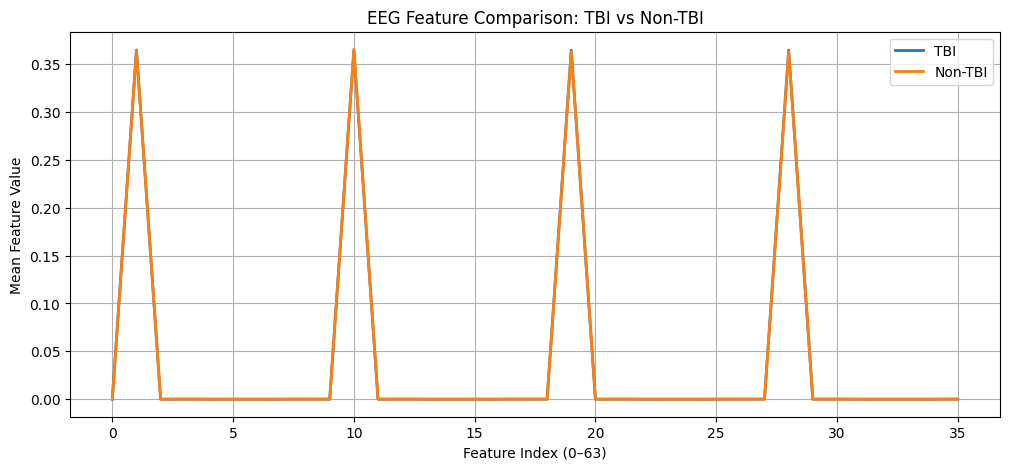

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Mean feature pattern
tbi_mean = np.mean(X_tbi, axis=0)
non_tbi_mean = np.mean(X_non_tbi, axis=0)

plt.figure(figsize=(12,5))
plt.plot(tbi_mean, label="TBI", linewidth=2)
plt.plot(non_tbi_mean, label="Non-TBI", linewidth=2)

plt.title("EEG Feature Comparison: TBI vs Non-TBI")
plt.xlabel("Feature Index (0–63)")
plt.ylabel("Mean Feature Value")
plt.legend()
plt.grid()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_287896\748810800.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X_tbi.flatten(), X_non_tbi.flatten()],


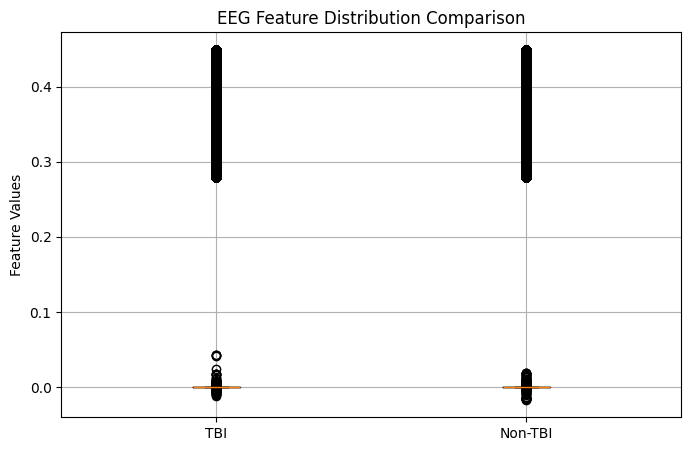

In [60]:
plt.figure(figsize=(8,5))

plt.boxplot([X_tbi.flatten(), X_non_tbi.flatten()],
            labels=["TBI", "Non-TBI"])

plt.title("EEG Feature Distribution Comparison")
plt.ylabel("Feature Values")
plt.grid()
plt.show()